In [1]:
import numpy as np

def _conditional_prob(w_dn, d):
    """
    P(z_{dn}^i=1 | z_{(-dn)}, w)
    """
    prob = np.empty(k)
    
    for i in range(k):
        # P(w_dn | z_i) * P(z_i | d)
        prob[i] = (n_iw[i, w_dn] + η) / (n_iw[i, :].sum() + V*η) * (n_di[d, i] + α) / (n_di[d, :].sum() + k*α)
    
    return prob / prob.sum()

def init_lda(docs, vocab, n_topic, random_state=0):
    
    global V, k, N, M, α, η, n_iw, n_di
    
    np.random.seed(random_state)

    V = len(vocab)
    k = n_topic  # number of topics
    N = np.array([doc.shape[0] for doc in docs])
    M = len(docs)

    print(f"V: {V}\nk: {k}\nN: {N[:10]}...\nM: {M}")

    # initialize α, η
    α = 0.1 #np.random.gamma(shape=100, scale=0.01, size=1)  # one for all k
    η = 0.1 #np.random.gamma(shape=100, scale=0.01, size=1)  # one for all V
    print(f"α: {α}\nη: {η}")

    n_iw = np.zeros((k, V), dtype=int)
    n_di = np.zeros((M, k), dtype=int)
    print(f"n_iw: dim {n_iw.shape}\nn_di: dim {n_di.shape}")

def _init_gibbs(docs, vocab, n_topic, n_gibbs=2000):
    """
    Initialize t=0 state for Gibbs sampling.
    Replace initial word-topic assignment 
    ndarray (M, N, N_GIBBS) in-place.
    """
    # initialize variables
    init_lda(docs, vocab, n_topic=n_topic)
    
    # word-topic assignment
    global assign
    N_max = max(N)
    assign = np.zeros((M, N_max, n_gibbs+1), dtype=int)
    print(f"assign: dim {assign.shape}")
    
    # initial assignment
    for d in range(M):
        for n in range(N[d]):
            # randomly assign topic to word w_{dn}
            w_dn = docs[d][n]
            assign[d, n, 0] = np.random.randint(k)

            # increment counters
            i = assign[d, n, 0]
            n_iw[i, w_dn] += 1
            n_di[d, i] += 1

def run_gibbs(docs, vocab, n_topic, n_gibbs=2000, verbose=True):
    """
    Run collapsed Gibbs sampling
    """
    # initialize required variables
    _init_gibbs(docs, vocab, n_topic, n_gibbs)
    
    if verbose:
        print("\n", "="*10, "START SAMPLER", "="*10)
        plot_params(0)
    
    # run the sampler
    for t in range(n_gibbs):
        for d in range(M):
            for n in range(N[d]):
                w_dn = docs[d][n]
                
                # decrement counter
                i_t = assign[d, n, t]  # previous assignment
                n_iw[i_t, w_dn] -= 1
                n_di[d, i_t] -= 1

                # assign new topics
                prob = _conditional_prob(w_dn, d)
                i_tp1 = np.argmax(np.random.multinomial(1, prob))

                # increment counter with new assignment
                n_iw[i_tp1, w_dn] += 1
                n_di[d, i_tp1] += 1
                assign[d, n, t+1] = i_tp1
        
        # print out status
        if verbose & ((t+1) % 10 == 0):
            print(f"Sampled {t+1}/{n_gibbs}")
            plot_params(t+1)

In [3]:
from nltk.corpus import reuters, stopwords
stops = stopwords.words("english")

reuters.words()[:10]

reuters.fileids()

['test/14826',
 'test/14828',
 'test/14829',
 'test/14832',
 'test/14833',
 'test/14839',
 'test/14840',
 'test/14841',
 'test/14842',
 'test/14843',
 'test/14844',
 'test/14849',
 'test/14852',
 'test/14854',
 'test/14858',
 'test/14859',
 'test/14860',
 'test/14861',
 'test/14862',
 'test/14863',
 'test/14865',
 'test/14867',
 'test/14872',
 'test/14873',
 'test/14875',
 'test/14876',
 'test/14877',
 'test/14881',
 'test/14882',
 'test/14885',
 'test/14886',
 'test/14888',
 'test/14890',
 'test/14891',
 'test/14892',
 'test/14899',
 'test/14900',
 'test/14903',
 'test/14904',
 'test/14907',
 'test/14909',
 'test/14911',
 'test/14912',
 'test/14913',
 'test/14918',
 'test/14919',
 'test/14921',
 'test/14922',
 'test/14923',
 'test/14926',
 'test/14928',
 'test/14930',
 'test/14931',
 'test/14932',
 'test/14933',
 'test/14934',
 'test/14941',
 'test/14943',
 'test/14949',
 'test/14951',
 'test/14954',
 'test/14957',
 'test/14958',
 'test/14959',
 'test/14960',
 'test/14962',
 'test/149

In [33]:
from matplotlib.gridspec import GridSpec
import matplotlib.pylab as plt

niter=0

for niter in range(0, 2000, 10):
    fig = plt.figure(figsize=(35,25))
    gs1 = GridSpec(2, 3, wspace=0.01, hspace=0.01)
    #gs1.update(left=0.1,right=0.9,top=0.965,bottom=0.03,wspace=0.01,hspace=0.01)
    plt.subplots_adjust(0, 0, 1, 0.95, 0.05, 0.05)
    ax1 = fig.add_subplot(gs1[:-1, :])
    ax2 = fig.add_subplot(gs1[-1, :-1])
    ax3 = fig.add_subplot(gs1[-1, -1])
    ax1.imshow(plt.imread('out/topics_{:05d}.png'.format(niter))[:,50:]), ax1.axis('off')
    ax2.imshow(plt.imread('out/heatmap_{:05d}.png'.format(niter))), ax2.axis('off')
    ax3.imshow(plt.imread('out/algo.png')), ax3.axis('off')
    plt.suptitle(f'Topic Model: Latent Dirichlet Allocation with Collapsed Gibbs Sampling (iter={niter})', size=35)
    plt.savefig('out/lda_{:05d}.png'.format(niter))
    plt.close()    

In [3]:
import pandas as pd
import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

df_train = pd.read_csv('learn-ai-bbc/BBC News Train.csv') #, index_col='id')
df_test = pd.read_csv('learn-ai-bbc/BBC News Test.csv') #, index_col='id')

def clean_text(txt):
    """""
    cleans the input text by following the steps:
    * replace contractions
    * replace dollar and pound values
    * remove punctuation
    * split into words
    * remove stopwords
    * remove leftover punctuations
    """""
    
    #remove punctuations
    txt  = "".join([char if char not in string.punctuation else ' ' for char in txt ])
    
    #process numbers / money
    txt = txt.replace('£', '$')
    txt = re.sub("\d+", " NUM ", txt) # change numbers to word " NUM "
    txt = re.sub('\s+', ' ', txt)   
    txt = txt.replace("NUM NUM", "NUM")
    txt = txt.replace("$ NUM", "dollar")
    txt = txt.replace("NUM bn", "dollar")
    txt = txt.replace("dollar bn", "dollar")
    txt = txt.replace("dollar dollar", "dollar")
    txt = txt.replace("NUM", "")
    for s in ['said', 'could', 'would', ' e ', ' p ', 'did', 'many', 'like', ' one', ' two', ' three', ' use ', ' used', 'also',
              'get', 'first', 'last', 'back', 'side', 'time', ' new', 'since']:
        txt = txt.replace(s, " ") # the word said is too frequent, we can see it with word cloud
    txt = re.sub('\s+', ' ', txt)   
    
    txt = txt.lower() # lowercase
    
    # split into words
    words = word_tokenize(txt)
    
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    
    # removing leftover punctuations
    words = [word for word in words if word.isalpha()]
    
    cleaned_text = ' '.join(words)
    return cleaned_text

# clean train and test tweets
df_train['Text'] = df_train['Text'].apply(lambda txt: clean_text(txt))
df_test['Text'] = df_test['Text'].apply(lambda txt: clean_text(txt))

df_train.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sandipan.Dey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sandipan.Dey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,ArticleId,Text,Category
0,1833,worldcom ex boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens maj...,business
3,1976,lifestyle governs mobile choice faster better ...,tech
4,917,enron bosses payout eighteen former enron dire...,business


In [4]:
# fetch titles only
# fetch 2000 docs only
trainset, testset = [], []
vocab = []

for row in df_train['Text'].sample(150).values:
    doc = row.split()
    trainset.append(doc)
    vocab += doc
        
vocab = list(set(vocab))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for i, w in enumerate(vocab)}

def seq_to_ix(seq, vocab=vocab):
    # len(vocab), which is the last index, is for the <unk> (unknown) token
    unk_idx = len(vocab)
    return np.array(list(map(lambda w: word_to_ix.get(w, unk_idx), seq)))

data = {
    "train": list(map(seq_to_ix, trainset)),
    #"test": list(map(seq_to_ix, testset))
}

docs = data["train"]
len(docs)

150

In [82]:
# fetch titles only
# fetch 2000 docs only
trainset, testset = [], []
vocab = []

for file_id in np.random.choice(list(filter(lambda x: x.startswith("train"), reuters.fileids())), 20):
    doc = [w.lower() for w in reuters.words(file_id) \
             if (w.isupper()) \
             if (w.lower() not in stops) \
             and (not w.isnumeric())]
    if doc:
        trainset.append(doc)
        vocab += doc
        
vocab = list(set(vocab))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for i, w in enumerate(vocab)}

def seq_to_ix(seq, vocab=vocab):
    # len(vocab), which is the last index, is for the <unk> (unknown) token
    unk_idx = len(vocab)
    return np.array(list(map(lambda w: word_to_ix.get(w, unk_idx), seq)))

data = {
    "train": list(map(seq_to_ix, trainset)),
    "test": list(map(seq_to_ix, testset))
}

docs = data["train"]

In [7]:
docs[1], len(docs)

(array([6472, 2601, 7405, 2864, 5888,  962, 7713,  787, 3585, 4181,  216,
        7055, 1108, 2221, 2213, 1790, 2013, 4936, 3570, 4045, 3361, 6921,
        1289, 4144, 6921,  787, 5138, 2601, 5253, 2625, 7552, 1190, 7782,
        7419, 1900, 2213, 4248, 7845, 1317, 5036, 5751, 4903, 5179, 1201,
        3966, 4153, 5245, 7176, 1706, 4144, 6937, 2601, 4968, 1635, 1698,
         199, 4761, 4144, 4299, 2625, 7552, 1323, 1201, 4880, 2400, 1750,
        5432, 7340, 6650, 7601, 2738, 4968,  382, 4144, 7707, 5800, 6650,
        1898, 6765, 4357, 7543, 3425, 5245, 3563, 2213, 6848, 7370, 2213,
        4108, 7489, 2601, 1345, 4433, 3798,  422, 1402, 5379, 1314, 6035,
        4144, 5828, 3216,  343, 4803, 4144, 2858, 4411, 2601, 1810,  925,
        4687, 7489, 7539, 1070, 1810, 6112, 4903, 4108, 5968, 6778, 7275,
        4968, 3045, 6824, 1455,  962,  613,  216, 6921, 6355, 1967, 6145,
        2884, 6472, 7747, 4981, 4369, 4174, 7300, 2956, 5598, 3559, 6592,
        4045, 3361, 6921, 5800, 4982, 

In [9]:
import matplotlib.pylab as plt
import seaborn as sns

def plot_params(niter):    
    β̂ = np.empty((k, V))
    θ̂ = np.empty((M, k))

    for j in range(V):
        for i in range(k):
            β̂[i, j] = (n_iw[i, j] + η) / (n_iw[i, :].sum() + V*η)

    for d in range(M):
        for i in range(k):
            θ̂[d, i] = (n_di[d, i] + α) / (n_di[d, :].sum() + k*α)
            
    plot_beta(β̂ , niter)
    plot_heatmap(β̂ , θ̂ , niter)        
    return (β̂ , θ̂ )

def plot_beta(β̂ , niter):
    plt.figure(figsize=(15,5))
    plt.subplots_adjust(0.1,0.24,1,0.9,0.15,0.3)
    for i in range(k):
        word_ix = np.argsort(-β̂[i])[:10]
        words = [ix_to_word[i] for i in word_ix]
        df = pd.DataFrame({'words': words, 'prob': β̂[i,word_ix]})
        plt.subplot(1,5,i+1)
        sns.barplot(x='words', y='prob', data=df, order=words)
        plt.title(f'Topic {i+1}', size=20)
        plt.xticks(rotation=90) 
    plt.savefig('out/topics_{:05d}.png'.format(niter))
    plt.close()
    
def plot_heatmap(β̂ , θ̂ , niter):
    words = ['england', 'game', 'win', 'wales', 'cup', 'ireland', 'team', 'france', 'half', 'play', 'mr', 'labour', 'blair', 'election', 'brown', 'party', 'government', 'minister', 'howard', 'prime',
'dollar', 'growth', 'economy', 'sales', 'year', 'bank', 'economic', 'market', 'china', 'oil', 'film', 'best', 'awards', 'award', 'actor', 'oscar', 'actress', 'films', 'director', 'star',
'mobile', 'people', 'music', 'phone', 'digital', 'technology', 'users', 'broadband', 'software', 'microsoft']
    plt.figure(figsize=(15,8))
    plt.subplot(121)
    #n_plot_words = 30 # 150
    #sns.heatmap(β̂.T[:n_plot_words], xticklabels=list(range(1,k+1)), 
    #            yticklabels=[ix_to_word[i] for i in range(n_plot_words)])
    ix = [word_to_ix[w] for w in words]
    sns.heatmap(β̂.T[ix], xticklabels=list(range(1,k+1)), 
                yticklabels=words)
    plt.xlabel("Topics", fontsize=14)
    plt.ylabel("Words", fontsize=14)
    plt.title("topic-word distribution", fontsize=16)

    plt.subplot(122)
    sns.heatmap(θ̂, xticklabels=list(range(1,k+1)), yticklabels=[])
    plt.xlabel("Topics", fontsize=14)
    plt.ylabel("Documents", fontsize=14)
    plt.title("document-topic distribution", fontsize=16)

    plt.tight_layout();
    plt.savefig('out/heatmap_{:05d}.png'.format(niter))
    plt.close()

k = 5
plot_params(0)

(array([[1.41639047e-05, 1.41639047e-05, 1.55802952e-04, ...,
         1.41639047e-05, 1.41639047e-05, 1.14727628e-03],
        [1.40662803e-05, 1.40662803e-05, 1.40662803e-05, ...,
         1.40662803e-05, 1.40662803e-05, 1.98334552e-03],
        [2.95807978e-04, 1.54947036e-04, 1.40860942e-05, ...,
         1.40860942e-05, 1.54947036e-04, 2.12700023e-03],
        [1.53863369e-04, 1.39875790e-05, 1.39875790e-05, ...,
         1.39875790e-05, 1.39875790e-05, 1.27286969e-03],
        [1.39836671e-05, 1.53820338e-04, 1.39836671e-05, ...,
         2.93657009e-04, 1.53820338e-04, 1.55218705e-03]]),
 array([[0.21894353, 0.19344262, 0.17522769, 0.25173042, 0.16065574],
        [0.19418417, 0.19095315, 0.19095315, 0.22649435, 0.19741519],
        [0.16431227, 0.19405204, 0.2535316 , 0.14944238, 0.23866171],
        [0.20576577, 0.20576577, 0.18054054, 0.21657658, 0.19135135],
        [0.18801498, 0.18052434, 0.18052434, 0.2329588 , 0.21797753],
        [0.23521445, 0.1765237 , 0.19909707, 0.1

In [10]:
run_gibbs(docs, vocab, n_topic=5, n_gibbs=2000) #10

V: 7882
k: 5
N: [274 309 134 277 133 221  93 130 229  92]...
M: 150
α: 0.1
η: 0.1
n_iw: dim (5, 7882)
n_di: dim (150, 5)
assign: dim (150, 771, 2001)

 ========== START SAMPLER ==========
Sampled 10/2000
Sampled 20/2000
Sampled 30/2000
Sampled 40/2000
Sampled 50/2000
Sampled 60/2000
Sampled 70/2000
Sampled 80/2000
Sampled 90/2000
Sampled 100/2000
Sampled 110/2000
Sampled 120/2000
Sampled 130/2000
Sampled 140/2000
Sampled 150/2000
Sampled 160/2000
Sampled 170/2000
Sampled 180/2000
Sampled 190/2000
Sampled 200/2000
Sampled 210/2000
Sampled 220/2000
Sampled 230/2000
Sampled 240/2000
Sampled 250/2000
Sampled 260/2000
Sampled 270/2000
Sampled 280/2000
Sampled 290/2000
Sampled 300/2000
Sampled 310/2000
Sampled 320/2000
Sampled 330/2000
Sampled 340/2000
Sampled 350/2000
Sampled 360/2000
Sampled 370/2000
Sampled 380/2000
Sampled 390/2000
Sampled 400/2000
Sampled 410/2000
Sampled 420/2000
Sampled 430/2000
Sampled 440/2000
Sampled 450/2000
Sampled 460/2000
Sampled 470/2000
Sampled 480/2000
Sampl

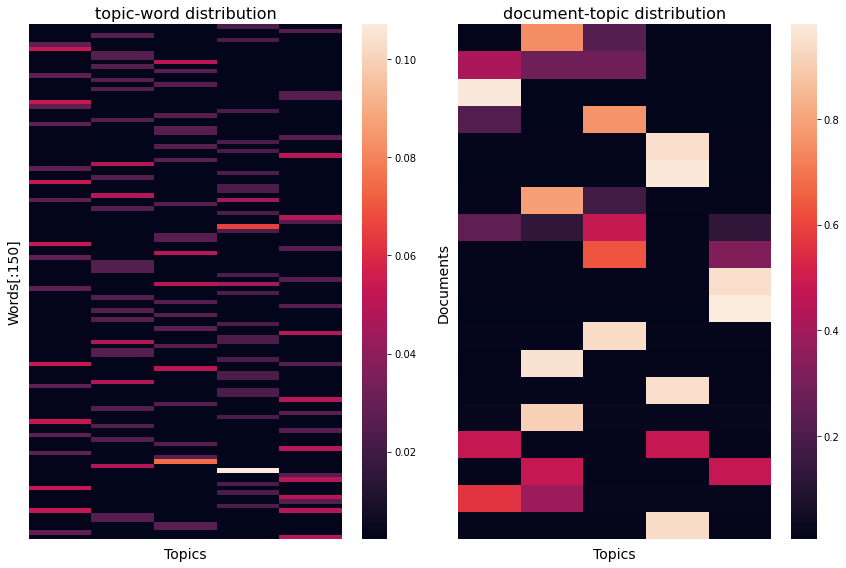

In [27]:
import matplotlib.pylab as plt
import seaborn as sns

plt.figure(figsize=(12,8))
plt.subplot(121)
n_plot_words = 30 #150
sns.heatmap(β̂.T[:n_plot_words], xticklabels=[], yticklabels=[])
plt.xlabel("Topics", fontsize=14)
plt.ylabel(f"Words[:{n_plot_words}]", fontsize=14)
plt.title("topic-word distribution", fontsize=16)

plt.subplot(122)
sns.heatmap(θ̂, xticklabels=[], yticklabels=[])
plt.xlabel("Topics", fontsize=14)
plt.ylabel("Documents", fontsize=14)
plt.title("document-topic distribution", fontsize=16)

plt.tight_layout();

In [28]:
for i in range(k):
    print([ix_to_word[i] for i in np.argsort(-β̂[i])[:10]])

['caesars', 'world', 'shares', 'acquisition', 'mts', 'negligible', 'number', 'al', 'trade', 'breaks']
['net', 'rises', 'note', 'qtr', 'inc', 'systems', 'unemployment', 'february', 'techniques', 'advanced']
['n', 'u', 'alcan', 'z', 'nz', 'makes', 'australia', 'plan', 'petroleum', 'reports']
['ec', 'us', 'trade', 'u', 'deficit', 'quarter', 'talk', 'french', 'syrian', 'sugar']
['norcros', 'shares', 'holdings', 'bidding', 'williams', 'stg', 'says', 'ordinary', 'mln', 'bank']


In [17]:
α, η

(array([1.18335424]), array([1.03715177]))

In [41]:
n_iw.shape

(5, 5601)

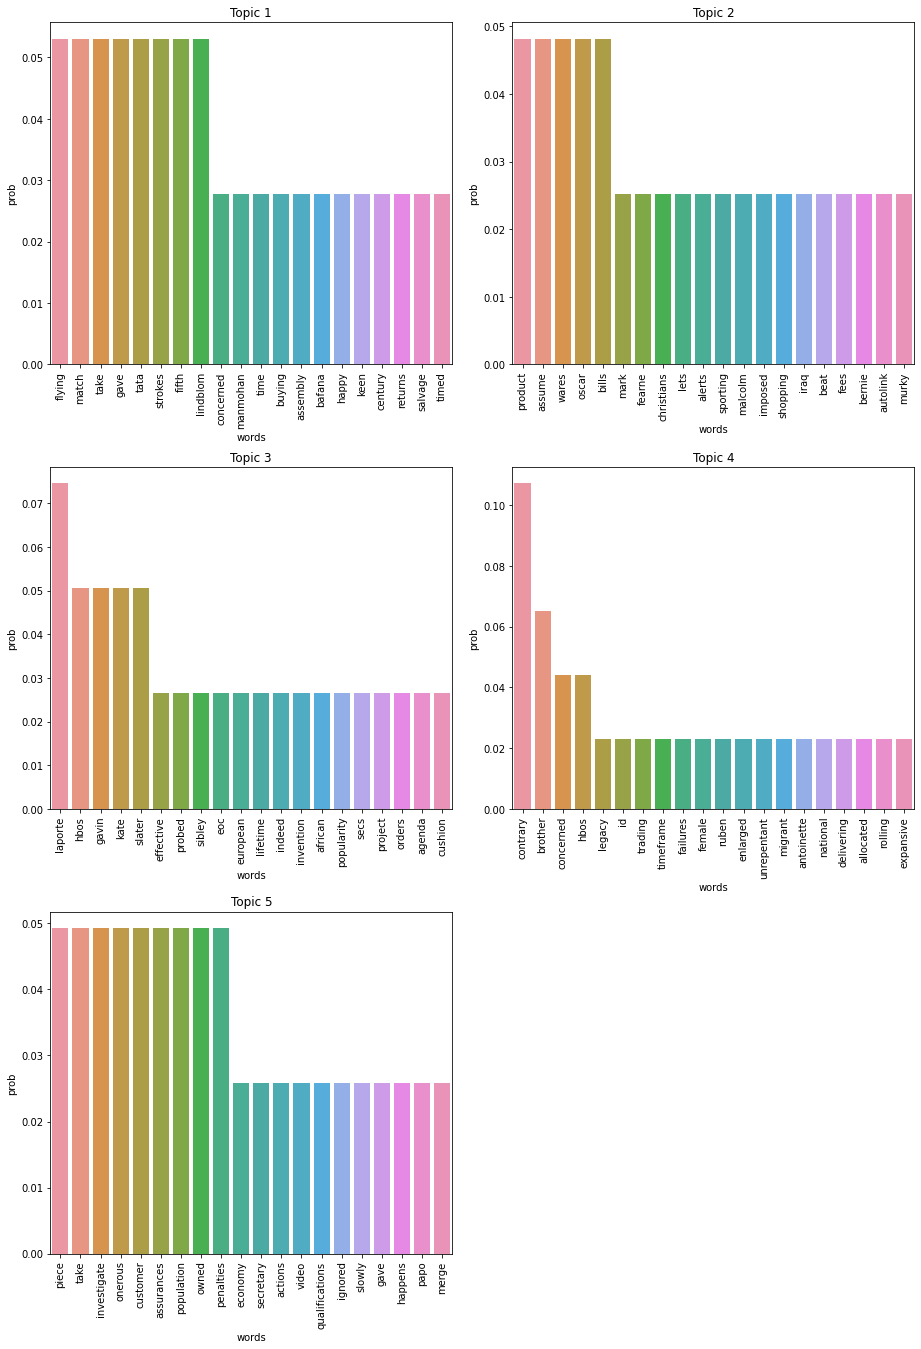

In [70]:
plt.figure(figsize=(12,18))
plt.subplots_adjust(0,0,1,0.95,0.15,0.3)
for i in range(k):
    word_ix = np.argsort(-β̂[i])[:20]
    words = [ix_to_word[i] for i in word_ix]
    df = pd.DataFrame({'words': words, 'prob': β̂[i,word_ix]})
    plt.subplot(3,2,i+1)
    sns.barplot(x='words', y='prob', data=df, order=words)
    plt.title(f'Topic {i+1}')
    plt.xticks(rotation=90) 
plt.show()

In [39]:
import numpy as np

def run_gibbs(docs, vocab, n_topic, n_gibbs=2000, random_state=0, verbose=True):
    """
    Run collapsed Gibbs sampling
    """
    # initialize required variables
    np.random.seed(random_state)

    V = len(vocab)
    k = n_topic  # number of topics
    N = np.array([doc.shape[0] for doc in docs])
    M = len(docs)

    print(f"V: {V}\nk: {k}\nN: {N[:10]}...\nM: {M}")

    # initialize α, η
    α = 0.1 #np.random.gamma(shape=100, scale=0.01, size=1)  # one for all k
    η = 0.01 #np.random.gamma(shape=100, scale=0.01, size=1)  # one for all V
    print(f"α: {α}\nη: {η}")

    n_iw = np.zeros((k, V), dtype=int)
    n_di = np.zeros((M, k), dtype=int)
    print(f"n_iw: dim {n_iw.shape}\nn_di: dim {n_di.shape}")
    
    # word-topic assignment
    N_max = max(N)
    z = np.zeros((M, N_max), dtype=int)
    print(f"assign: dim {z.shape}")
    
    # initial assignment
    for d in range(M):
        for n in range(N[d]):
            # randomly assign topic to word w_{dn}
            w_dn = docs[d,n]
            z[d, n] = np.random.randint(k)
            # increment counters
            i = z[d, n]
            n_iw[i, w_dn] += 1
            n_di[d, i] += 1

    if verbose:
        print("\n", "="*10, "START SAMPLER", "="*10)
        plot_params(0, n_iw, n_di, V, M, N, k, η, α)
    
    # run the sampler
    for t in range(n_gibbs):
        for d in range(M):
            for n in range(N[d]):
                w_dn = docs[d,n]
                
                # decrement counter
                i_t = z[d, n]  # previous assignment
                n_iw[i_t, w_dn] -= 1
                n_di[d, i_t] -= 1

                # assign new topics
                prob = np.empty(k)
                for i in range(k):
                    # P(w_dn | z_i) * P(z_i | d)
                    prob[i] = (n_iw[i, w_dn] + η) / (n_iw[i, :].sum() + V*η) * (n_di[d, i] + α) / (n_di[d, :].sum() + k*α)
                prob /= prob.sum()

                i_tp1 = np.argmax(np.random.multinomial(1, prob))

                # increment counter with new assignment
                n_iw[i_tp1, w_dn] += 1
                n_di[d, i_tp1] += 1
                z[d, n] = i_tp1
        
        # print out status
        if verbose & ((t+1) % 10 == 0):
            print(f"Sampled {t+1}/{n_gibbs}")
            plot_params(t+1, n_iw, n_di, V, M, N, k, η, α)

In [35]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pylab as plt

(train_X, train_y), (test_X, test_y) = mnist.load_data()
#train_X.shape
n = 200
digits = train_X[np.random.choice(len(train_X), n)]
digits = digits.reshape(n, -1)
digits.shape

(200, 784)

In [44]:
import seaborn as sns

def plot_params(niter, n_iw, n_di, V, M, N, k, η, α):    
    β̂ = np.empty((k, V))
    θ̂ = np.empty((M, k))

    for j in range(V):
        for i in range(k):
            β̂[i, j] = (n_iw[i, j] + η) / (n_iw[i, :].sum() + V*η)

    #for d in range(M):
    #    for i in range(k):
    #        θ̂[d, i] = (n_di[d, i] + α) / (n_di[d, :].sum() + k*α)
    print(n_iw[0])        
    print(n_iw[1])        
    plot_beta(β̂ , niter)
    return (β̂ ) #, θ̂ )

def plot_beta(β̂ , niter):
    plt.figure(figsize=(10,5))
    plt.subplots_adjust(0,0,1,0.9,0.05,0.05)
    plt.gray()
    for i in range(k):
        plt.subplot(2,5,i+1), plt.imshow(β̂[i].reshape(28,28)), plt.axis('off'), plt.title(f'Topic (component) {i+1}', size=12)
    plt.savefig('out/digits_{:05d}.png'.format(niter))
    plt.close()

In [45]:
run_gibbs(digits, np.arange(784), n_topic=10, n_gibbs=2000) #10

V: 784
k: 10
N: [784 784 784 784 784 784 784 784 784 784]...
M: 200
α: 0.1
η: 0.01
n_iw: dim (10, 784)
n_di: dim (200, 10)
assign: dim (200, 784)

 ========== START SAMPLER ==========
[12561    10     7    14    19     9    18     7    12    10    10    11
    18     8    11     9    10    12     6     8     4    16     8     8
     6     7    10    13     6     9     7     6    12     5     5     9
     4    10    11    11     8    10     5    15     8     6     3    10
     5     5     7    10     7     8     7     2     5    15     9     8
    10    10     9     4    11     2     5     3     7    10     3     6
     7     9     2     7     8     2     4     9     8     4     5     5
    14     8     5     2     2     6     0     7     4     6     8     4
     4     6     2     2     4    10     7     4     6     4     8     3
     7    10     2     4     8     3     7     2     4     3     4     4
     6     6     2     5     6     3     6     1    24     4     6     5
     8     6 

KeyboardInterrupt: 

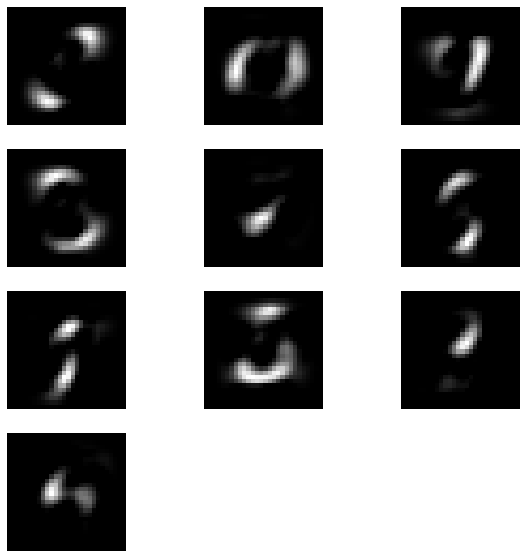

In [71]:
plt.figure(figsize=(10,10))
plt.gray()
for i in range(svd.components_.shape[0]):
    plt.subplot(4,3,i+1), plt.imshow(nmf.components_[i].reshape(28,28)), plt.axis('off')
plt.show()

In [20]:
from sklearn.decomposition import NMF, LatentDirichletAllocation
lda = LatentDirichletAllocation(
    n_components=10,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)
lda.fit(digits)

LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                          max_iter=5, random_state=0)

In [22]:
lda.components_.shape

(10, 784)

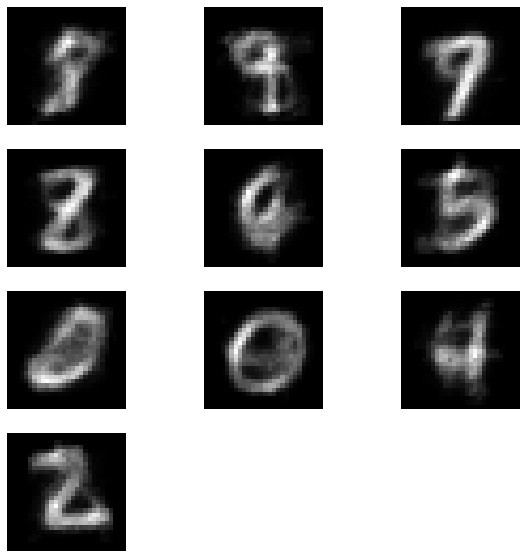

In [21]:
plt.figure(figsize=(10,10))
plt.gray()
for i in range(lda.components_.shape[0]):
    plt.subplot(4,3,i+1), plt.imshow(lda.components_[i].reshape(28,28)), plt.axis('off')
plt.show()

In [24]:
import lda
model = lda.LDA(n_topics=10, random_state=0, n_iter=100)
model.fit(digits) #doctest: +ELLIPSIS +NORMALIZE_WHITESPACE

INFO:lda:n_documents: 200
INFO:lda:vocab_size: 784
INFO:lda:n_words: 5296146
INFO:lda:n_topics: 10
INFO:lda:n_iter: 100
INFO:lda:<0> log likelihood: -43084896
INFO:lda:<10> log likelihood: -37508297
INFO:lda:<20> log likelihood: -32728496
INFO:lda:<30> log likelihood: -32266901
INFO:lda:<40> log likelihood: -32071509
INFO:lda:<50> log likelihood: -31976141
INFO:lda:<60> log likelihood: -31921527
INFO:lda:<70> log likelihood: -31896683
INFO:lda:<80> log likelihood: -31901927
INFO:lda:<90> log likelihood: -31888269
INFO:lda:<99> log likelihood: -31881064


In [29]:
model.eta

0.01

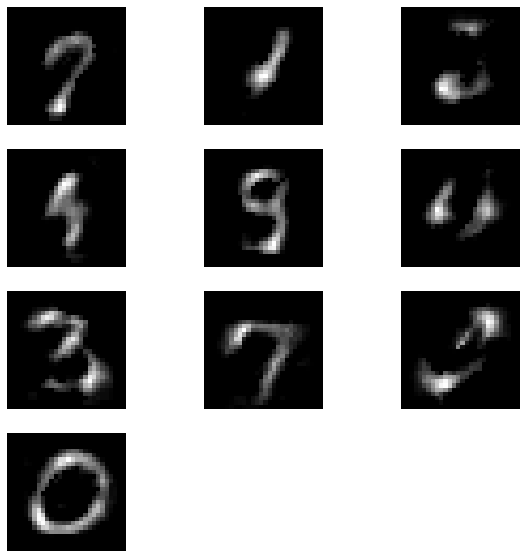

In [26]:
plt.figure(figsize=(10,10))
plt.gray()
for i in range(model.components_.shape[0]):
    plt.subplot(4,3,i+1), plt.imshow(model.components_[i].reshape(28,28)), plt.axis('off')
plt.show()

In [6]:
from sklearn.cluster import KMeans
import numpy as np
kmeans = KMeans(n_clusters=10, random_state=0).fit(digits)

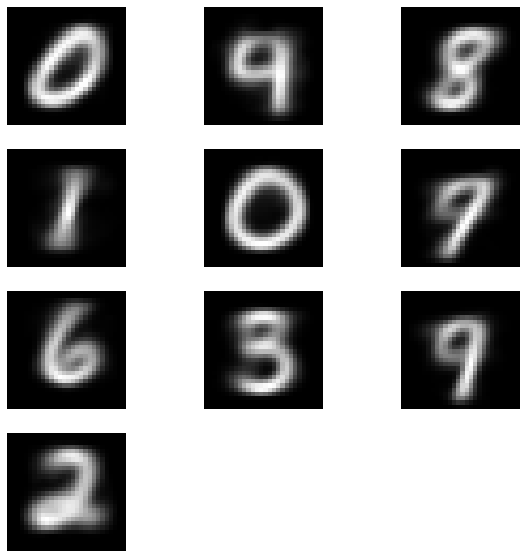

In [10]:
import matplotlib.pylab as plt
plt.figure(figsize=(10,10))
plt.gray()
for i in range(kmeans.cluster_centers_.shape[0]):
    plt.subplot(4,3,i+1), plt.imshow(kmeans.cluster_centers_[i].reshape(28,28)), plt.axis('off')
plt.show()

In [10]:
from sklearn.decomposition import FastICA
ica = FastICA(n_components=10, random_state=0)
ica.fit(digits)

FastICA(n_components=10, random_state=0)

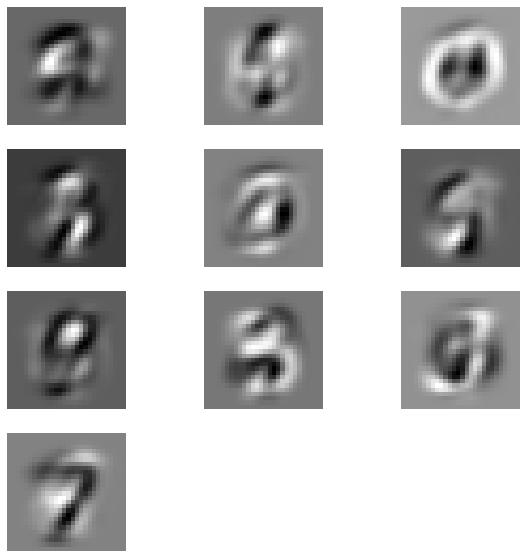

In [11]:
import matplotlib.pylab as plt
plt.figure(figsize=(10,10))
plt.gray()
for i in range(ica.components_.shape[0]):
    plt.subplot(4,3,i+1), plt.imshow(ica.components_[i].reshape(28,28)), plt.axis('off')
plt.show()

In [21]:
def plot_images(comps, name):
    plt.figure(figsize=(12,12))
    plt.subplots_adjust(0,0,1,0.9,0.05,0.08)
    plt.gray()
    n = len(comps)
    m = int(np.ceil(np.sqrt(n)))
    for i in range(n):
        plt.subplot(m,m,i+1), plt.imshow(comps[i].reshape(28,28)), plt.axis('off'), plt.title(f'component {i}', size=12)
    plt.suptitle(f'Unsupervised Algorithm: {name}, #components: {n}', size=15)
    plt.savefig('out/fig_{}_{:02d}.png'.format(name, n))
    plt.close()

from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation, FastICA
from sklearn.cluster import KMeans
algos = [TruncatedSVD, NMF, LatentDirichletAllocation, FastICA, KMeans]
names = ['Truncated SVD', 'NonNeg Matrix Factorization', 'Latent Dirichlet Allocation', 'Independent Comp Analysis', 'KMeans Clustering']
#for i in range(len(algos)):
for i in range(4,5):
    for k in range(2,17):
        print(names[i], k)
        model = algos[i](n_clusters=k, random_state=0) if names[i] == 'KMeans Clustering' else algos[i](n_components=k, random_state=0)   
        model.fit(digits)
        comp = model.cluster_centers_ if names[i] == 'KMeans Clustering' else model.components_            
        plot_images(comp, names[i])

KMeans Clustering 2
KMeans Clustering 3
KMeans Clustering 4
KMeans Clustering 5
KMeans Clustering 6
KMeans Clustering 7
KMeans Clustering 8
KMeans Clustering 9
KMeans Clustering 10
KMeans Clustering 11
KMeans Clustering 12
KMeans Clustering 13
KMeans Clustering 14
KMeans Clustering 15
KMeans Clustering 16


In [29]:
for k in range(2,17):
    plt.figure(figsize=(25,7))
    plt.gray()
    plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
    for i in range(len(algos)):
        im = plt.imread('out/fig_{}_{:02d}.png'.format(names[i], k))
        plt.subplot(1,5,i+1), plt.imshow(im[50:,:,:]), plt.axis('off'), plt.title(names[i], size=20)
    plt.suptitle(f'Latent Features with Topic Models (TSVD, NMF, LDA) & other (ICA, KMeans) Unsupervised Algorithms (#Components = {k}) for MNIST', size=25)
    plt.savefig('out1/fig_{:02d}.png'.format(k))
    plt.close()

In [5]:
from bertopic import BERTopic
# pip install bertopic[vision] --ignore-installed llvmlite --user
# pip install --upgrade 'urllib3==1.26.7' --user
topic_model = BERTopic(nr_topics=10)
topic_model.fit(digits)
topics.shape, probs.shape

TypeError: Make sure that the iterable only contains strings.

In [9]:
dir(BERTopic)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_auto_reduce_topics',
 '_c_tf_idf',
 '_cluster_embeddings',
 '_create_topic_vectors',
 '_extract_embeddings',
 '_extract_representative_docs',
 '_extract_topics',
 '_extract_words_per_topic',
 '_get_param_names',
 '_guided_topic_modeling',
 '_images_to_text',
 '_map_predictions',
 '_map_probabilities',
 '_preprocess_text',
 '_reduce_dimensionality',
 '_reduce_to_n_topics',
 '_reduce_topics',
 '_save_representative_docs',
 '_sort_mappings_by_frequency',
 '_top_n_idx_sparse',
 '_top_n_values_sparse',
 '_update_topic_size',
 'approximate_distribution',
 'find_topics',
 'fit',
 'fit_transform',
 'generate_topic_labels',
 'ge

In [4]:
from lda2vec import LDA2Vec

model = LDA2Vec(784, 100, 10, 256)
model.add_component(n, 10)
model.fit(digits)

ModuleNotFoundError: No module named 'en_core_web_md'